## Churn Analysis and Customer Intelligence

#### By Ruchi Asthana

## 1. Data Import

In [1]:
# Importing dotenv file.
# ! pip install python-dotenv (if not installed already)
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST")
db = os.getenv("MYSQL_DB")

print(user, host)   # Just to confirm it works

root localhost


In [2]:
# Connecting to the MYSQL Database.
! pip install mysql-connector-python
import mysql.connector

conn = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=db
)

In [3]:
# Showing all table names from the database
cursor = conn.cursor()
cursor.execute("SHOW TABLES;")

tables = cursor.fetchall()
for t in tables:
    print(t[0])

db_customer
db_subscription
db_support


In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# create dataframe for each table
dfs = {}

for t in tables:
    table_name = t[0]
    dfs[table_name] = pd.read_sql(f"SELECT * FROM {table_name};", conn)

# Show results
for name, df in dfs.items():
    print(f"\nTable: {name}")
    print(df.head())


Table: db_customer
   customerid    name country        state  gender         dob interests  \
0  0002-ORFBO  keshav   India  Maharashtra    Male  12-04-1982    travel   
1  0003-MKNFE  raghav   India    Karnataka    Male  23-11-1995             
2  0004-TLHLJ  lalita   India        Delhi  Female  15-02-1978     movie   
3  0011-IGKFF   mohan   India     Nagaland    Male  30-08-2001             
4  0013-EXCHZ    mira   India        Delhi  Female  05-05-1990     drama   

  pincode  
0          
1          
2          
3          
4          

Table: db_subscription
   customerid subscription_start_date subscription_type renewal_date  \
0  0002-ORFBO              15-03-2021          Refferal   15-03-2025   
1  0003-MKNFE              01-08-2020              Paid   01-08-2024   
2  0004-TLHLJ              20-11-2022           Organic   20-11-2025   
3  0011-IGKFF              10-05-2019              Paid   10-05-2025   
4  0013-EXCHZ              05-01-2023          Refferal   05-01-202

C:\Users\Ruchi\AppData\Local\Temp\ipykernel_22728\3995618258.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[table_name] = pd.read_sql(f"SELECT * FROM {table_name};", conn)


## 2. Data Cleaning

In [6]:
# customer table

In [7]:
 dfs["db_customer"].head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,12-04-1982,travel,
1,0003-MKNFE,raghav,India,Karnataka,Male,23-11-1995,,
2,0004-TLHLJ,lalita,India,Delhi,Female,15-02-1978,movie,
3,0011-IGKFF,mohan,India,Nagaland,Male,30-08-2001,,
4,0013-EXCHZ,mira,India,Delhi,Female,05-05-1990,drama,


In [8]:
dfs["db_customer"].tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,19-08-1994,,
17,0021-IKXGC,vishakha,India,Rajasthan,Female,02-09-2000,,
18,0022-TCJCI,raghvendra,India,Telangana,Male,30-12-1983,,
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,14-05-1991,,
20,0023-UYUPN,sudevi,India,Maharashtra,Women,06-10-1977,,


In [9]:
dfs["db_customer"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     21 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   21 non-null     object
 7   pincode     21 non-null     object
dtypes: object(8)
memory usage: 1.4+ KB


In [10]:
# a. rename column name to customer_name
# b. drop columns interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

In [11]:
# a. rename column name to customer_name
dfs["db_customer"].rename(columns = {'name' : 'customer_name'}, inplace= True)

In [12]:
# b. drop columns - interest and pincode
dfs["db_customer"].drop(columns=['interests', 'pincode'], inplace=True)  # using col name

In [13]:
dfs["db_customer"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        21 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [14]:
# c. change data type - dob
dfs["db_customer"]["dob"] = pd.to_datetime(
    dfs["db_customer"]["dob"],
    format="%d-%m-%Y"
)


In [15]:
# d. data standardization - gender
dfs["db_customer"]["gender"].unique()
dfs["db_customer"]["gender"] = dfs["db_customer"]["gender"].replace({'Men' : 'Male', 'Women' : 'Female'})

In [16]:
np.array(['Male', 'Female'], dtype=object)

array(['Male', 'Female'], dtype=object)

In [17]:
# e. fix missing values - country
dfs["db_customer"]['country'].unique()
# converting empty strings in the database to real NaN values.
dfs["db_customer"].replace(
    {'country': ['', ' ', 'NULL', 'None']},
    pd.NA,
    inplace=True
)
# number of missing values in country column
int(dfs["db_customer"]["country"].isna().sum())

3

In [18]:
dfs["db_customer"]['country'].unique()
# country and state - unique value pair
# Creating state → country map from non-null rows
state_country_mapping = dfs['db_customer'].dropna(subset=['country']).set_index('state')['country'].to_dict()
# Fill the missing country using State
dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna(dfs['db_customer']['state'].map(state_country_mapping))

In [19]:
int(dfs['db_customer']['country'].isna().sum()) # no null value in country col

0

In [20]:
# subscription table

In [21]:
dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,15-03-2021,Refferal,15-03-2025,Standard,Annual,,,13.99,627,12
1,0003-MKNFE,01-08-2020,Paid,01-08-2024,Premium,Annual,10-09-2024,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,20-11-2022,Organic,20-11-2025,Basic,Monthly,,,6.99,210,34
3,0011-IGKFF,10-05-2019,Paid,10-05-2025,Premium,Annual,,,22.99,1725,8
4,0013-EXCHZ,05-01-2023,Refferal,05-01-2024,Standard,Monthly,28-02-2024,Too expensive,13.99,195,88


In [22]:
dfs['db_subscription'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        21 non-null     object 
 7   cancellation_reason      21 non-null     object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [23]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
dfs["db_subscription"]["subscription_start_date"] = pd.to_datetime(
    dfs["db_subscription"]["subscription_start_date"],
    format="%d-%m-%Y"
)
dfs["db_subscription"]["renewal_date"] = pd.to_datetime(
    dfs["db_subscription"]["renewal_date"],
    format="%d-%m-%Y"
)
dfs["db_subscription"]["cancellation_date"] = pd.to_datetime(
    dfs["db_subscription"]["cancellation_date"],
    format="%d-%m-%Y"
)
dfs['db_subscription'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      21 non-null     object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [24]:
# support table

In [25]:
dfs['db_support'].head()

,customerid,complaint_date,escalations,csat_score,comment
0,0003-MKNFE,28-08-2024,N,60,service issue
1,0003-MKNFE,28-08-2024,Y,10,demaned refund
2,0013-EXCHZ,20-01-2024,Y,20,
3,0013-MHZWF,18-03-2025,N,90,guidance to renew
4,0013-SMEOE,01-11-2024,N,30,


In [26]:
dfs['db_support'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   comment         9 non-null      object
dtypes: int64(1), object(4)
memory usage: 492.0+ bytes


In [27]:
# change data type to date - complaint_date

dfs['db_support']['complaint_date'] = pd.to_datetime(dfs['db_support']['complaint_date'], format="%d-%m-%Y")
dfs['db_support'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   comment         9 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 492.0+ bytes


## 3. Feature Engineering & Data Analysis

#### Create a new col

In [28]:
# create a new col using existing col - churn flag
# Customer is churned if cancellation_date is not null
dfs['db_subscription']['churn_flag'] = np.where(dfs['db_subscription']['cancellation_date'].notna(), 1, 0)
dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [29]:
# first fix support table duplicates then merge
# Note: while merging dfs always check the shape before and after
df = (dfs['db_subscription']
            .merge(dfs['db_customer'], on = 'customerid', how= 'left')
            .merge(dfs['db_support'], on = 'customerid', how= 'left') )
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN


#### Export dataframe

In [30]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

#### Data Analysis

In [31]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  34.78 %


In [32]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  65.22 %


In [33]:
# 3 a. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           66.67
1   Premium           25.00
2  Standard           22.22


In [34]:
# 3 b. Churn by Contract type
churn_by_contract = (df.groupby('contract_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_contract)

  contract_type  churn_rate_pct
0        Annual           15.38
1       Monthly           60.00


In [35]:
# 4 a. Churn by state + sum(revenue) & count of users
churn_by_state = (
    df.groupby('state')['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate_pct')
)

monthly_revenue_by_state = (
    df.groupby('state')['monthly_charges']
      .sum()
      .reset_index(name='monthly_revenue')
)

users_by_state = (
    df.groupby('state')['customerid']
      .count()
      .reset_index(name='total_users')
)

# Merge all three into one final output
state_summary = (
    churn_by_state
    .merge(monthly_revenue_by_state, on='state')
    .merge(users_by_state, on='state')
)

state_summary

,state,churn_rate_pct,monthly_revenue,total_users
0,Delhi,25.00,52.96,4
1,Karnataka,100.00,33.97,3
2,Kathmandu,0.00,20.98,2
3,Maharashtra,0.00,50.97,3
4,Meghalaya,66.67,42.97,3
5,Nagaland,0.00,22.99,1
6,Rajasthan,0.00,36.98,2
7,Telangana,66.67,47.97,3
8,Uttar Pradesh,0.00,115.98,2


In [36]:
# 4 b. Churn by subscription type + sum(revenue) & count of users
churn_by_subscription_type = (
    df.groupby('subscription_type')['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate_pct')
)

monthly_revenue_by_subscription_type = (
    df.groupby('subscription_type')['monthly_charges']
      .sum()
      .reset_index(name='monthly_revenue')
)

users_by_subscription_type = (
    df.groupby('subscription_type')['customerid']
      .count()
      .reset_index(name='total_users')
)

# Merge all three into one final output
state_summary = (
    churn_by_subscription_type
    .merge(monthly_revenue_by_subscription_type, on='subscription_type')
    .merge(users_by_subscription_type, on='subscription_type')
)

state_summary

,subscription_type,churn_rate_pct,monthly_revenue,total_users
0,Organic,0.00,145.91,9
1,Paid,28.57,187.93,7
2,Refferal,85.71,91.93,7


In [37]:
# 5 a. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.51


In [38]:
# 5 b. Average Customer Age
today = pd.Timestamp.today()
df['age'] = (today - df['dob']).dt.days / 365
average_age = df['age'].mean()
print('average_age = ',round(average_age,2))

average_age =  37.04


In [39]:
# 6. Avg Customer Tenure
# count of days users have used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure))

Avg Tenure (Days) =  1483


In [79]:
# 7 a. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", round(revenue_at_risk,2))

Revenue at Risk (Rs 'K') = 103.92


In [80]:
# 7 b. CLTV lost from churned users
cltv_loss = df.loc[df['churn_flag']==1, 'cltv'].sum()
print("CLTV Lost = ",cltv_loss)

CLTV Lost =  3239


In [41]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  21.74 %


In [42]:
# 9. Avg Complaint Per User
complaint_count = (
    df.assign(complaint_flag = df['complaint_date'].notna())['complaint_flag'].sum()
)
print("total complaints = ",complaint_count)
avg_complaints = complaint_count / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

total complaints =  9
Avg Compliants Per User =  0.43


In [43]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.72


In [54]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default='N/A')
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,comment,age,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,44.441096,2004.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,service issue,30.816438,1501.0,high
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,demaned refund,30.816438,1501.0,high
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,48.597260,1389.0,low
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,25.043836,2679.0,low


## 4. Visualization using Matplotlib

In [58]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [59]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'age',
       'tenure_days', 'churn_risk'],
      dtype='object')

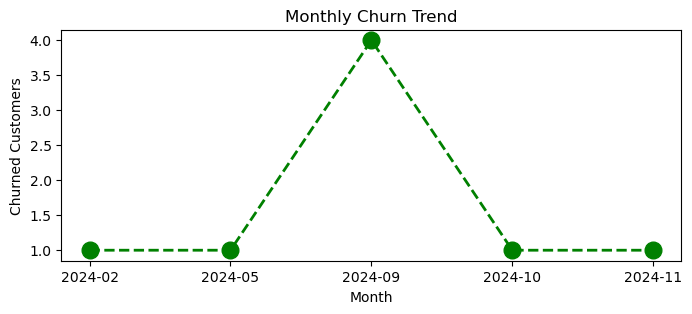

In [60]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

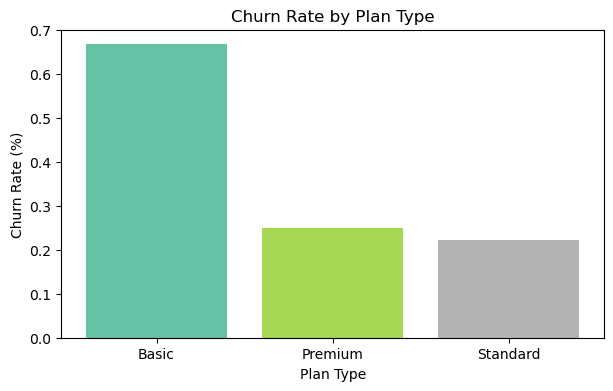

In [61]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

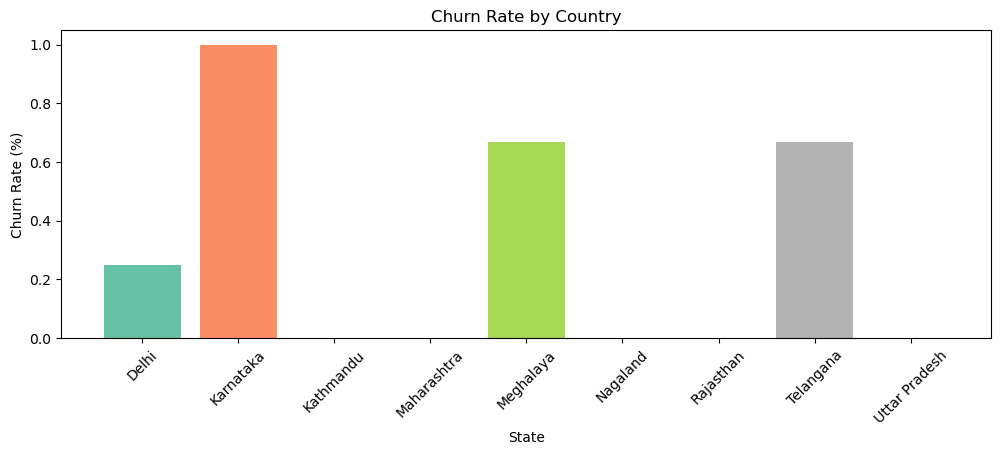

In [62]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## 5. Visulaization using Seaborn

In [50]:
# Heatmap (Correlation Matrix)

In [63]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [64]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Premium,Annual,91,1,high,1
3,Basic,Monthly,34,0,low,0
4,Premium,Annual,8,0,low,0


In [65]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [66]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

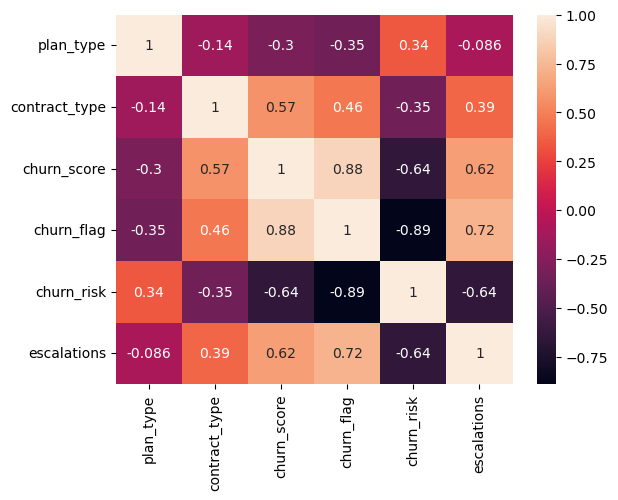

In [67]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [68]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : ['Standard' 'Premium' 'Basic']
contract_type : ['Annual' 'Monthly']
churn_risk : ['low' 'high' 'med']


In [69]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [70]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Premium,Annual,91,1,high,1
3,Basic,Monthly,34,0,low,0
4,Premium,Annual,8,0,low,0


In [71]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,2,1,91,1,2,1
3,0,0,34,0,0,0
4,2,1,8,0,0,0


<Axes: >

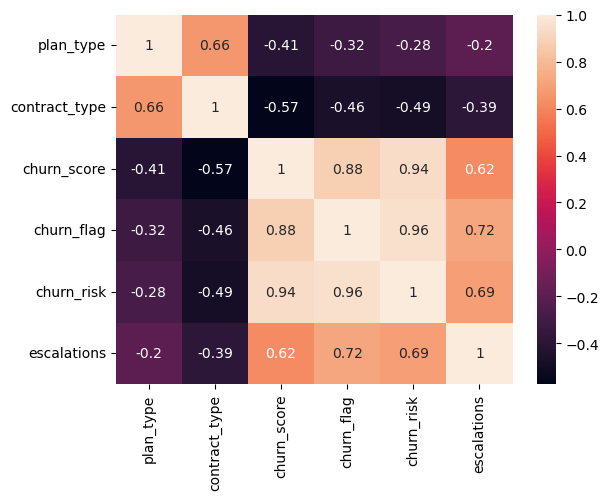

In [72]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

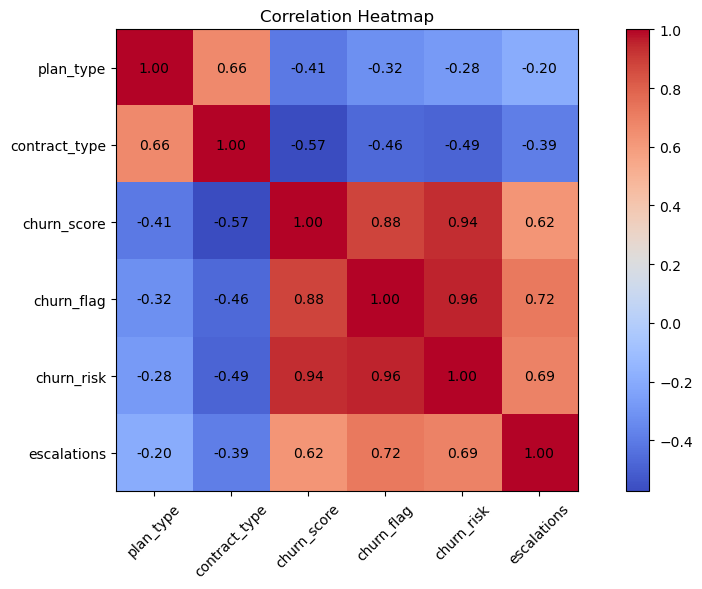

In [73]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

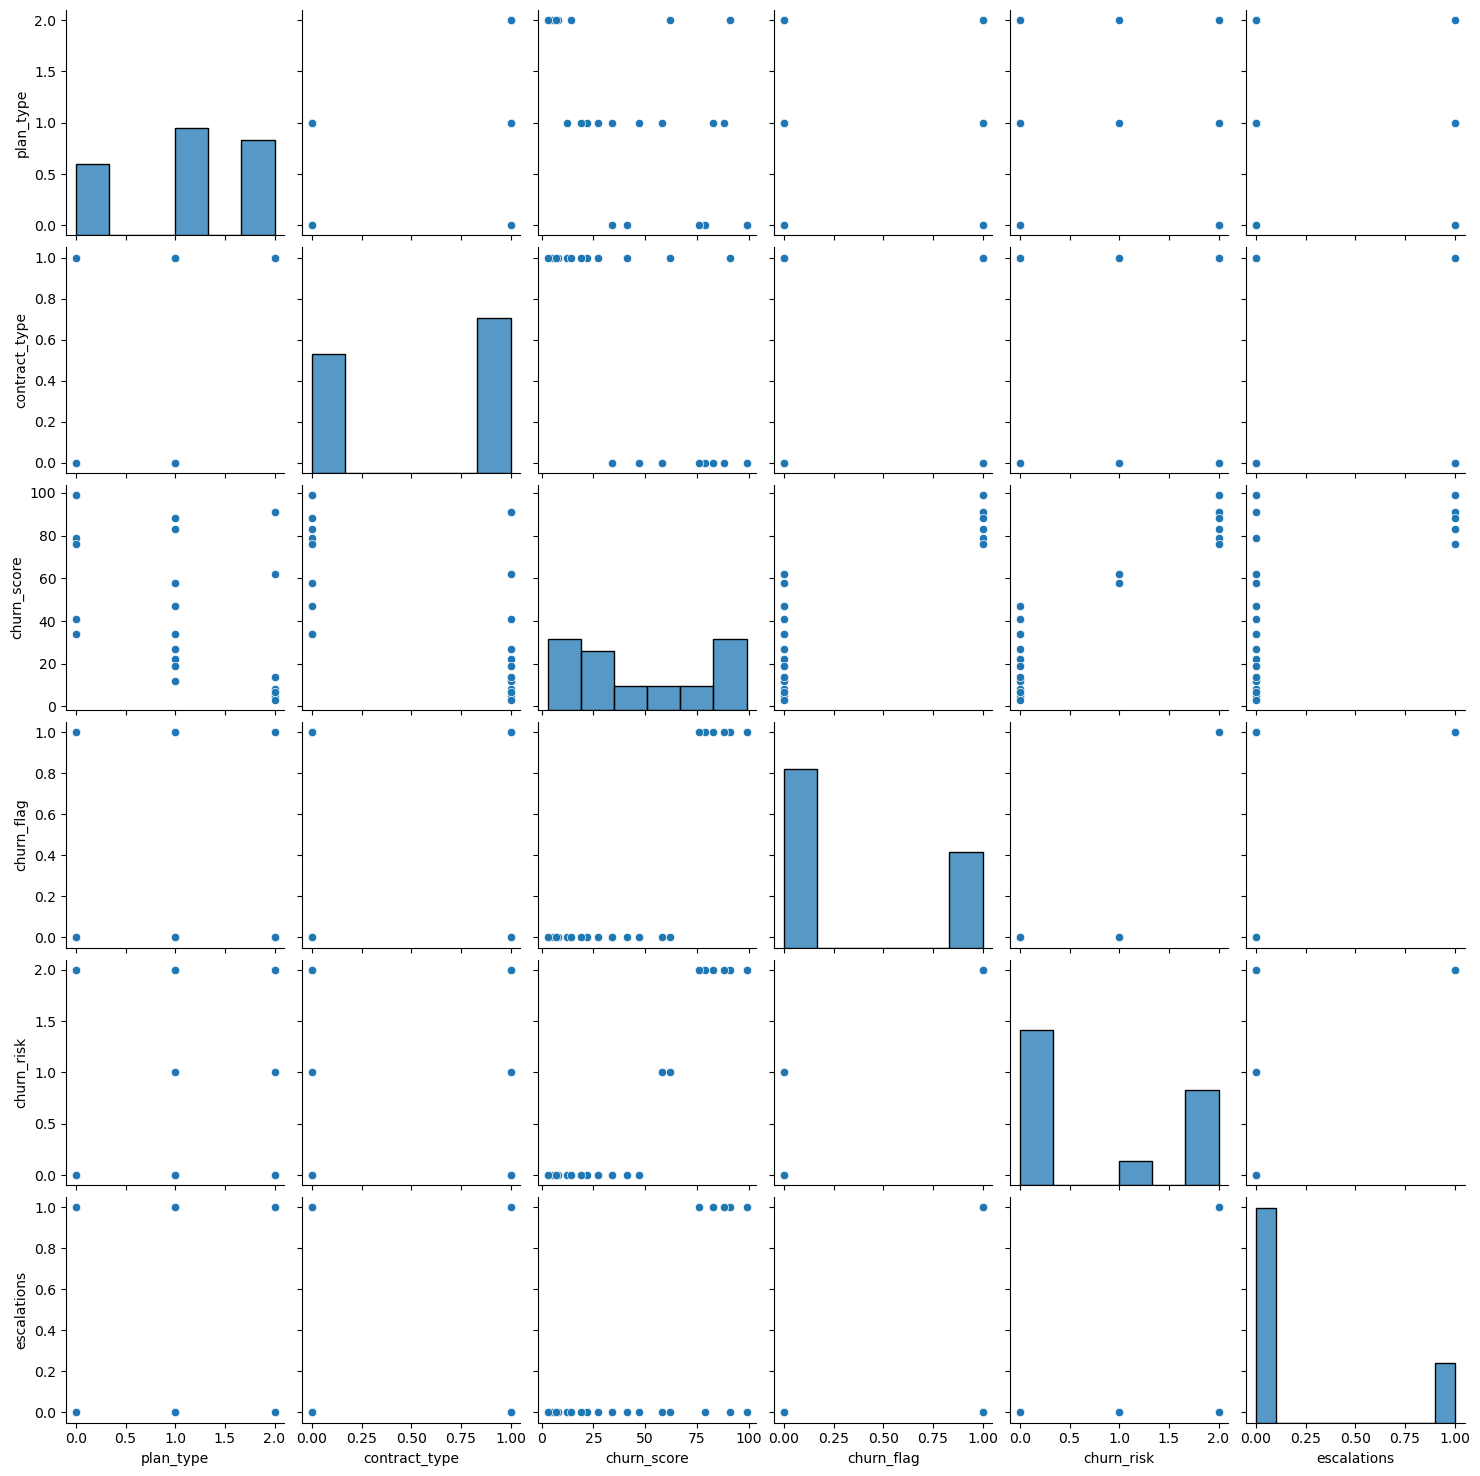

In [74]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [75]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

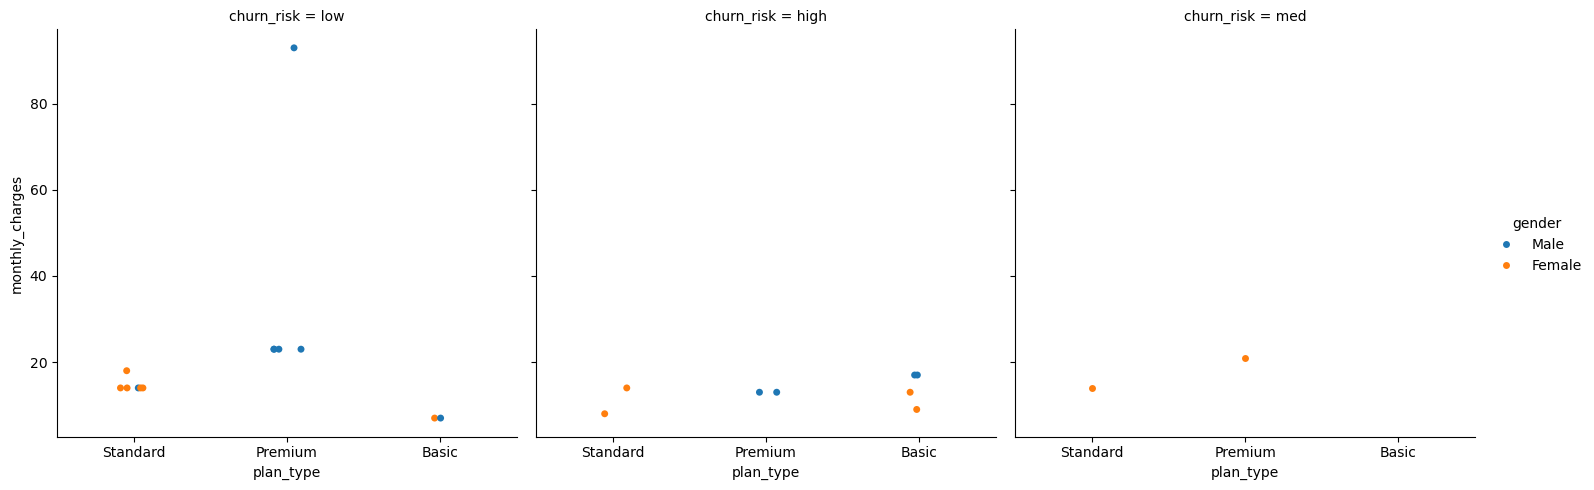

In [76]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

#### Pivot table

In [77]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.666667
Premium,0.250000
Standard,0.222222


In [78]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.666667,5,69.94
Premium,0.250000,7,231.92
Standard,0.222222,9,123.91


## Project Completed :)